In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV

import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

## EDA and Data Loading

In [3]:
print("Loading Pima Indians Diabetes dataset from CSV...")
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
column_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

# Load directly into DataFrame
df_pima = pd.read_csv(url, names=column_names)

X_pima = df_pima.drop('Outcome', axis=1)
y_pima = df_pima['Outcome'] # Already 0 and 1, no mapping needed

print(f"Target Values: {y_pima.unique()}")
print(f"Data Shape: {X_pima.shape}")


# --- UNCOMMENT BELOW TO USE THIS DATASET INSTEAD ---
X = X_pima
y = y_pima.rename('diagnosis') # Renaming to match previous code's expectation if needed
target_names = np.array(['No Diabetes', 'Diabetes'])
df = pd.concat([X, y], axis=1)
print("Switched to Pima Indians Diabetes Dataset")


Loading Pima Indians Diabetes dataset from CSV...
Target Values: [1 0]
Data Shape: (768, 8)
Switched to Pima Indians Diabetes Dataset


## Alternative Dataset: Pima Indians Diabetes
For comparison purposes, we can load the **Pima Indians Diabetes Database**. This is another classic binary classification dataset where the goal is to predict whether a patient has diabetes based on diagnostic measurements.

We can load this easily using `fetch_openml` from scikit-learn.
- **Classes**: `tested_positive` (1) vs `tested_negative` (0)
- **Features**: 8 numeric features (Glucose, BMI, Age, etc.)


In [4]:
#observing head
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,diagnosis
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
# checking for missing values, shape and data types
print("---DataFrame Shape---", df.shape)
print("\n---Data Types---\n", df.dtypes)
print("\n---Missing Values---\n", df.isnull().sum())

---DataFrame Shape--- (768, 9)

---Data Types---
 Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
diagnosis                     int64
dtype: object

---Missing Values---
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
diagnosis                   0
dtype: int64


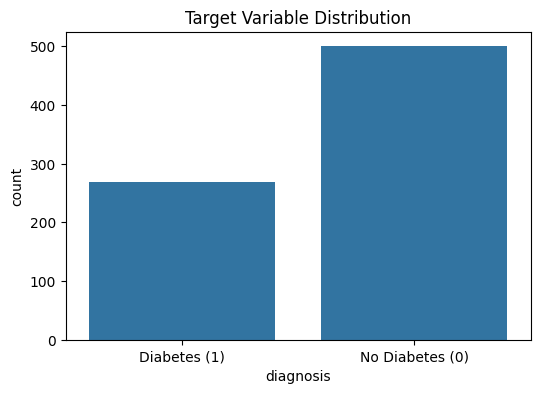

diagnosis
0    0.651042
1    0.348958
Name: proportion, dtype: float64


In [6]:
# checking if the classes are balanced
plt.figure(figsize=(6, 4))
sns.countplot(x=y.map({0: 'No Diabetes (0)', 1: 'Diabetes (1)'}))
plt.title('Target Variable Distribution')
plt.show()

print(y.value_counts(normalize=True))

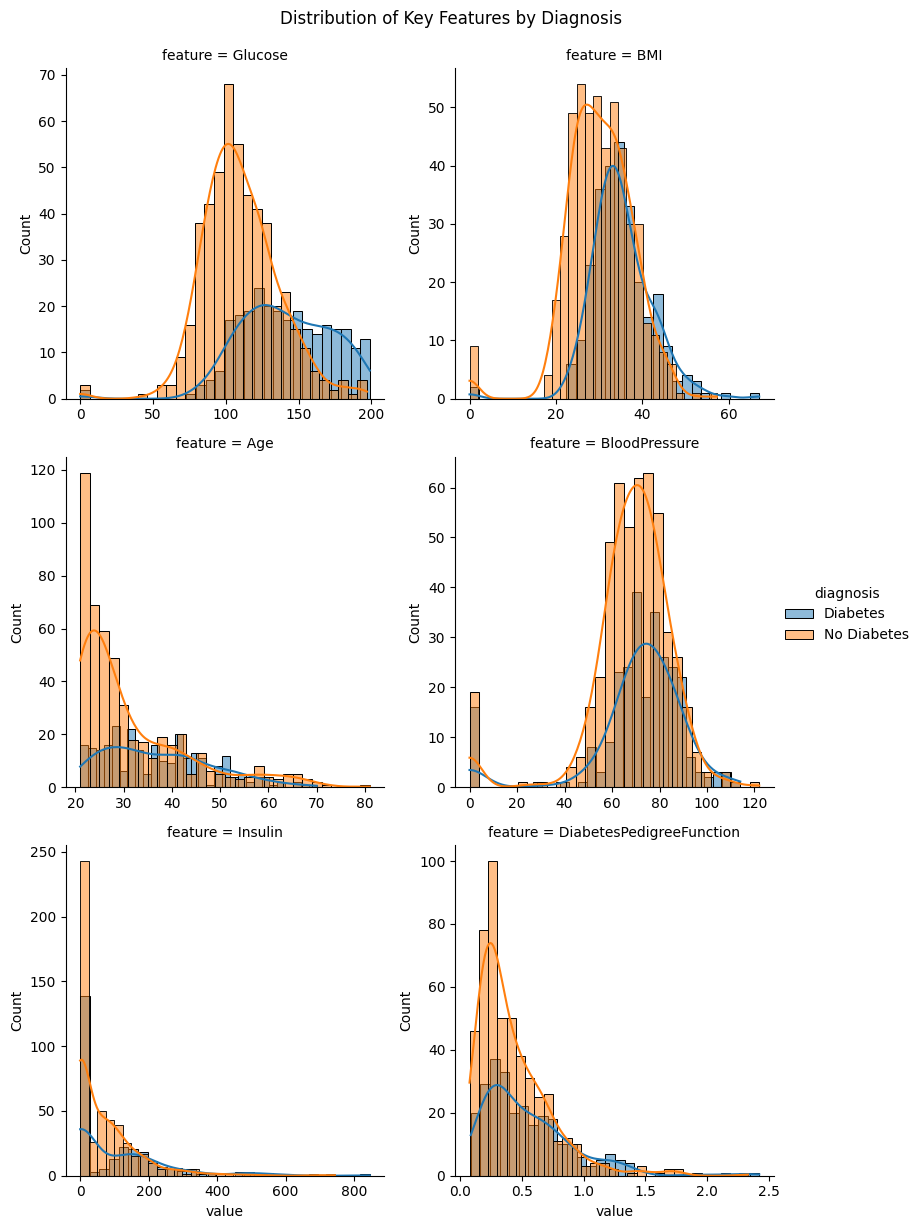

In [7]:
features_to_plot = ['Glucose', 'BMI', 'Age', 'BloodPressure', 'Insulin', 'DiabetesPedigreeFunction']
df_plot = df.melt(id_vars='diagnosis', value_vars=features_to_plot, var_name='feature')
df_plot['diagnosis'] = df_plot['diagnosis'].map({0: 'No Diabetes', 1: 'Diabetes'})

g = sns.FacetGrid(df_plot, col='feature', hue='diagnosis', col_wrap=2, sharex=False, sharey=False, height=4)
g.map(sns.histplot, 'value', kde=True, bins=30)
g.add_legend()
plt.suptitle('Distribution of Key Features by Diagnosis', y=1.02)
plt.show()

As we can see from the visual above:

**Most Predictive Features (Strong Separation):**

Glucose: This is clearly the strongest predictor. There is a distinct shift to the right for the "Diabetes" group (blue). People with diabetes tend to have much higher glucose levels (centered around 120-150+), while those without diabetes (orange) are centered around 100.
Age: There is a noticeable difference in distribution. The "No Diabetes" group is heavily skewed towards younger ages (20s), while the "Diabetes" group is more spread out across older ages. This suggests age is a significant risk factor.
BMI: Similar to Glucose, the "Diabetes" distribution is shifted to the right, indicating higher BMI correlates with a positive diagnosis, though there is significant overlap.

**Less Predictive Features (High Overlap):**

BloodPressure: The distributions for both groups are nearly identical and centered around the same mean. This suggests blood pressure alone is not a strong differentiator for diabetes in this specific dataset.
Insulin & DiabetesPedigreeFunction: Both show heavy right skews for both groups with significant overlap, making them likely less powerful as standalone predictors compared to Glucose or BMI.

## Data Preprocessing

We'll create a `Pipeline` that first scales the data using `StandardScaler` and then runs the model.

From there, we will create pipelines for our models, build, train, and get baseline results.



X_train shape: (537, 8)
X_test shape: (231, 8)
y_train shape: (537,)
y_test shape: (231,)
After SMOTE (train) counts of label '1': 350
After SMOTE (train) counts of label '0': 350 



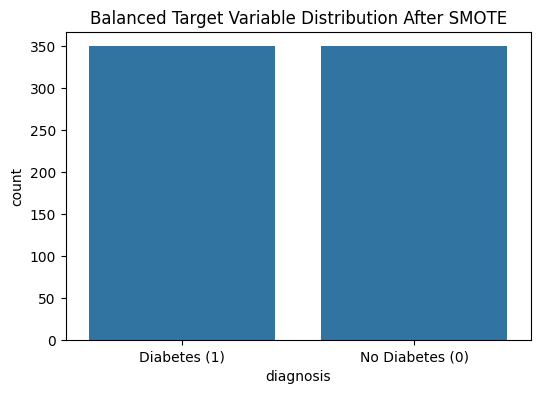

In [8]:
# we are doing a 70/30 split of the data for training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("After SMOTE (train) counts of label '1': {}".format(sum(y_train_res==1)))
print("After SMOTE (train) counts of label '0': {} \n".format(sum(y_train_res==0)))

plt.figure(figsize=(6, 4))
sns.countplot(x=y_train_res.map({0: 'No Diabetes (0)', 1: 'Diabetes (1)'}))
plt.title('Balanced Target Variable Distribution After SMOTE')
plt.show()

In [9]:
scaler = StandardScaler()
scaler

,copy,True
,with_mean,True
,with_std,True


## Model Implementation

### Logistic Regression

Creating a pipeling for logistic regression, train the model and evaluate

In [10]:
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(random_state=42, solver= 'liblinear'))
])

# training
lr_pipeline.fit(X_train_res, y_train_res)

# get predictions on the test set
y_pred_lr = lr_pipeline.predict(X_test)
y_proba_lr = lr_pipeline.predict_proba(X_test)[:, 1]

# calculating metrics
accuracy_lr = accuracy_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_proba_lr)

print("--- Logistic Regression Test Results ---")
print(f"Accuracy: {accuracy_lr:.4f}")
print(f"AUC: {auc_lr:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=target_names))


--- Logistic Regression Test Results ---
Accuracy: 0.7532
AUC: 0.8391

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.83      0.79      0.81       150
    Diabetes       0.64      0.69      0.66        81

    accuracy                           0.75       231
   macro avg       0.73      0.74      0.73       231
weighted avg       0.76      0.75      0.76       231



### SVM

We will create a pipeline for linear SVM, train, and evaluate the model

In [11]:
svm_linear_pipeline = Pipeline([
    ('scaler', StandardScaler()),  # using a new instance of scaler
    ('svm_linear', SVC(kernel='linear', probability=True, random_state=42))
])

# training the model
svm_linear_pipeline.fit(X_train_res, y_train_res)

# evaluating the linear svm and checking performance agains the logisitic regression model
y_pred_svm_linear = svm_linear_pipeline.predict(X_test)
y_proba_svm_linear = svm_linear_pipeline.predict_proba(X_test)[:, 1]

# calculating metrics
accuracy_svm_linear = accuracy_score(y_test, y_pred_svm_linear)
auc_svm_linear = roc_auc_score(y_test, y_proba_svm_linear)

print("--- Linear SVM Test Results ---")
print(f"Accuracy: {accuracy_svm_linear:.4f}")
print(f"AUC: {auc_svm_linear:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm_linear, target_names=target_names))


--- Linear SVM Test Results ---
Accuracy: 0.7706
AUC: 0.8386

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.84      0.79      0.82       150
    Diabetes       0.66      0.73      0.69        81

    accuracy                           0.77       231
   macro avg       0.75      0.76      0.75       231
weighted avg       0.78      0.77      0.77       231



### Non-Linear Kernel (RBF)
Implementing a Non-linear kernel (RBF) and using GridSearchCV to find the best ```C``` and ```gamma``` parameters.

In [12]:
# creating a pipeline for RBF SVM
svm_rbf_pipeline = Pipeline([
    ('scaler', StandardScaler()),  # using a new instance of scaler
    ('svm_rbf', SVC(kernel='rbf', probability=True, random_state=42))
])

# defining parameter grid for GridSearchCV
param_grid = {
    'svm_rbf__C': [0.1, 0.5, 0.75, 1, 1.1, 1.2, 1.3, 10],
    'svm_rbf__gamma': [1, 0.1, 0.01, 0.001, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.75, 1.8, 1.9, 2.0]
}

# setting up GridSearchCV to find the best parameters using 5-fold cross-validation
svm_grid = GridSearchCV(svm_rbf_pipeline, param_grid, refit=True, verbose=2, cv=5, scoring='roc_auc')

# train the model (gridsearchcv will find the best model parameters and retrain it on all training data)
svm_grid.fit(X_train_res, y_train_res)
print(f"Best Parameters from GridSearchCV: {svm_grid.best_params_}")


Fitting 5 folds for each of 120 candidates, totalling 600 fits
[CV] END ...................svm_rbf__C=0.1, svm_rbf__gamma=1; total time=   0.0s
[CV] END ...................svm_rbf__C=0.1, svm_rbf__gamma=1; total time=   0.1s
[CV] END ...................svm_rbf__C=0.1, svm_rbf__gamma=1; total time=   0.0s
[CV] END ...................svm_rbf__C=0.1, svm_rbf__gamma=1; total time=   0.0s
[CV] END ...................svm_rbf__C=0.1, svm_rbf__gamma=1; total time=   0.0s
[CV] END .................svm_rbf__C=0.1, svm_rbf__gamma=0.1; total time=   0.0s
[CV] END .................svm_rbf__C=0.1, svm_rbf__gamma=0.1; total time=   0.0s
[CV] END .................svm_rbf__C=0.1, svm_rbf__gamma=0.1; total time=   0.0s
[CV] END .................svm_rbf__C=0.1, svm_rbf__gamma=0.1; total time=   0.0s
[CV] END .................svm_rbf__C=0.1, svm_rbf__gamma=0.1; total time=   0.0s
[CV] END ................svm_rbf__C=0.1, svm_rbf__gamma=0.01; total time=   0.0s
[CV] END ................svm_rbf__C=0.1, svm_r

In [13]:
# Now w will make predictions and evaluate the model
y_pred_svm_rbf = svm_grid.predict(X_test)
y_proba_svm_rbf = svm_grid.predict_proba(X_test)[:, 1]

# calculating metrics
accuracy_svm_rbf = accuracy_score(y_test, y_pred_svm_rbf)
auc_svm_rbf = roc_auc_score(y_test, y_proba_svm_rbf)

print("--- RBF SVM Test Results ---")
print(f"Accuracy: {accuracy_svm_rbf:.4f}")
print(f"AUC: {auc_svm_rbf:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm_rbf, target_names=target_names))

--- RBF SVM Test Results ---
Accuracy: 0.6883
AUC: 0.7382

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.71      0.88      0.79       150
    Diabetes       0.60      0.33      0.43        81

    accuracy                           0.69       231
   macro avg       0.65      0.61      0.61       231
weighted avg       0.67      0.69      0.66       231



## Model Comparison and Evaluation

In [14]:
def get_metrics(y_true, y_pred, y_proba, target_names):
    '''
    Calculates accuracy, auc, sensitivity, and specificity.
    '''
    # getting values from the confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    accuracy = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_proba)

    # Sensitivity (Recall) = How many Diabetes cases did we find? (Higher is better)
    # This directly measures our goal of minimizing False Negatives.
    sensitivity = tp / (tp + fn)  

    # Specificity = How many Non Diabetes cases did we correctly identify? (Higher is better)
    # This measures how well we avoid False Positives.
    specificity = tn / (tn + fp) 

    # getting raw counts
    false_negatives = fn
    false_positives = fp

    # report = classification_report(y_true, y_pred, target_names=target_names, output_dict=True)
    # precision_m = report['malignant']['precision']
    # recall_m = report['malignant']['recall']
    # precision_b = report['benign']['precision']
    # recall_b = report['benign']['recall']
    return {
        'Accuracy': accuracy,
        'AUC': auc,
        'Sensitivity (Diabetes Recall)': sensitivity,
        'Specificity (Non Diabetes Recall)': specificity,
        'False Negatives (FN)': false_negatives,
        'False Positives (FP)': false_positives
    }

In [15]:
# getting metics for all models
metrics_lr = get_metrics(y_test, y_pred_lr, y_proba_lr, target_names)
metrics_svm_linear = get_metrics(y_test, y_pred_svm_linear, y_proba_svm_linear, target_names)
metrics_svm_rbf = get_metrics(y_test, y_pred_svm_rbf, y_proba_svm_rbf, target_names)

# creating a comparison df
comparison_df = pd.DataFrame({
    'Logistic Regression': metrics_lr,
    'SVM Linear': metrics_svm_linear,
    'SVM RBF (Tuned)': metrics_svm_rbf
})

print("--- Model Performance Comparison ---")
print(comparison_df)

comparison_df

--- Model Performance Comparison ---
                                   Logistic Regression  SVM Linear  \
Accuracy                                      0.753247    0.770563   
AUC                                           0.839095    0.838560   
Sensitivity (Diabetes Recall)                 0.691358    0.728395   
Specificity (Non Diabetes Recall)             0.786667    0.793333   
False Negatives (FN)                         25.000000   22.000000   
False Positives (FP)                         32.000000   31.000000   

                                   SVM RBF (Tuned)  
Accuracy                                  0.688312  
AUC                                       0.738230  
Sensitivity (Diabetes Recall)             0.333333  
Specificity (Non Diabetes Recall)         0.880000  
False Negatives (FN)                     54.000000  
False Positives (FP)                     18.000000  


,Logistic Regression,SVM Linear,SVM RBF (Tuned)
Accuracy,0.753247,0.770563,0.688312
AUC,0.839095,0.838560,0.738230
Sensitivity (Diabetes Recall),0.691358,0.728395,0.333333
Specificity (Non Diabetes Recall),0.786667,0.793333,0.880000
False Negatives (FN),25.000000,22.000000,54.000000
False Positives (FP),32.000000,31.000000,18.000000


--- Linear Regression R^2 Analysis ---
                    Feature  R2 Score
1                   Glucose  0.227111
5                       BMI  0.081437
0               Pregnancies  0.053437
7                       Age  0.052833
4                   Insulin  0.026757
6  DiabetesPedigreeFunction  0.020904
2             BloodPressure  0.004379
3             SkinThickness  0.002852


C:\Users\edgar\AppData\Local\Temp\ipykernel_23172\615001960.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='R2 Score', y='Feature', data=r2_df, palette='viridis')


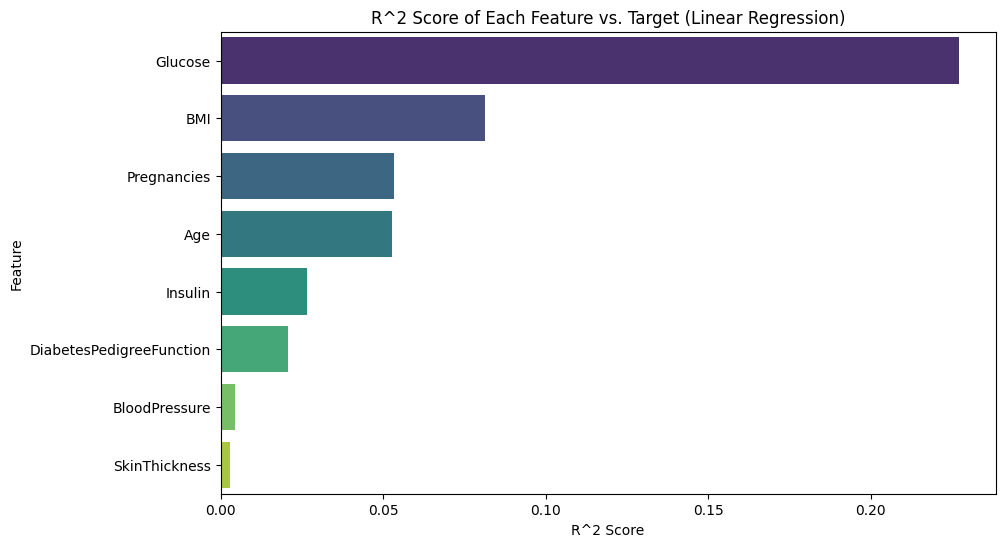

In [16]:
r2_results = []

print("--- Linear Regression R^2 Analysis ---")

# Iterate through each feature to calculate R^2 against the target
for feature in X_train.columns:
    # Initialize Linear Regression model
    lin_reg = LinearRegression()
    
    # Reshape data for single feature (keep as DataFrame/2D array)
    X_feature_train = X_train[[feature]]
    
    # Fit the model
    lin_reg.fit(X_feature_train, y_train)
    
    # Predict and calculate R^2 on the training set
    y_pred_lin = lin_reg.predict(X_feature_train)
    r2 = r2_score(y_train, y_pred_lin)
    
    r2_results.append({'Feature': feature, 'R2 Score': r2})

# Create DataFrame and sort by R^2
r2_df = pd.DataFrame(r2_results).sort_values(by='R2 Score', ascending=False)

print(r2_df)

# Plotting the R2 scores
plt.figure(figsize=(10, 6))
sns.barplot(x='R2 Score', y='Feature', data=r2_df, palette='viridis')
plt.title('R^2 Score of Each Feature vs. Target (Linear Regression)')
plt.xlabel('R^2 Score')
plt.show()

### 10-fold CV on different models

According to "Data-Driven Machine-Learning Methods for Diabetes Risk Prediction" by Elias DritsasORCID and Maria Trigka, a variety of models were tested to compare their performance on this same data. We will recreate this exercise.

One thing to consider is the rebalancing using SMOTE to prevent leakage.

In [17]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_validate, StratifiedKFold
from imblearn.pipeline import Pipeline as ImbPipeline 

# Define the cross-validation strategy (10-Fold)
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Define the models dictionary
# Note: For SVM RBF, I am using the best params you found earlier (C=1, gamma=1.5)
models = {
    'Logistic Regression': LogisticRegression(solver='liblinear', random_state=42),
    'SVM Linear': SVC(kernel='linear', probability=True, random_state=42),
    'SVM RBF (Tuned)': SVC(kernel='rbf', C=1, gamma=1.7, probability=True, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Naive Bayes': GaussianNB()
}

# Define metrics we want to track
scoring_metrics = {
    'accuracy': 'accuracy',
    'auc': 'roc_auc',
    'sensitivity': 'recall', # Recall for the positive class (Diabetes)
    'precision': 'precision'
}

In [18]:
results_list = []

print(f"{'Model':<25} {'Mean Accuracy':<15} {'Mean AUC':<10} {'Mean Sensitivity':<15}")
print("-" * 65)

for name, model in models.items():
    # Create a pipeline that:
    # 1. Applies SMOTE (only on the training folds)
    # 2. Scales the data (StandardScaler)
    # 3. Fits the classifier
    pipeline = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('scaler', StandardScaler()),
        ('classifier', model)
    ])
    
    # Run 10-Fold CV using the ORIGINAL X_train and y_train (not the pre-smoted ones)
    # The pipeline handles the SMOTE internally for each fold.
    cv_results = cross_validate(
        pipeline, 
        X_train, 
        y_train, 
        cv=cv, 
        scoring=scoring_metrics,
        n_jobs=-1 # Use all processors
    )
    
    # Store results
    mean_acc = cv_results['test_accuracy'].mean()
    mean_auc = cv_results['test_auc'].mean()
    mean_sens = cv_results['test_sensitivity'].mean()
    
    print(f"{name:<25} {mean_acc:.4f}          {mean_auc:.4f}     {mean_sens:.4f}")
    
    results_list.append({
        'Model': name,
        'Accuracy': mean_acc,
        'AUC': mean_auc,
        'Sensitivity': mean_sens,
        'Precision': cv_results['test_precision'].mean()
    })

Model                     Mean Accuracy   Mean AUC   Mean Sensitivity
-----------------------------------------------------------------
Logistic Regression       0.7469          0.8257     0.7123
SVM Linear                0.7561          0.8229     0.7070
SVM RBF (Tuned)           0.6762          0.7497     0.3325
KNN                       0.7283          0.7702     0.7275
Random Forest             0.7488          0.8095     0.6696
Naive Bayes               0.7451          0.8146     0.6646



--- Detailed 10-Fold CV Results (Sorted by Sensitivity) ---


,Model,Accuracy,AUC,Sensitivity,Precision
3,KNN,0.728337,0.770192,0.727485,0.593188
0,Logistic Regression,0.746855,0.825673,0.712281,0.623170
1,SVM Linear,0.756150,0.822882,0.707018,0.640634
4,Random Forest,0.748847,0.809486,0.669591,0.633730
5,Naive Bayes,0.745108,0.814570,0.664620,0.636081
2,SVM RBF (Tuned),0.676240,0.749657,0.332456,0.562933


C:\Users\edgar\AppData\Local\Temp\ipykernel_23172\1758664178.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=cv_df, ax=axes[0], palette='viridis')
C:\Users\edgar\AppData\Local\Temp\ipykernel_23172\1758664178.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='AUC', data=cv_df, ax=axes[1], palette='magma')
C:\Users\edgar\AppData\Local\Temp\ipykernel_23172\1758664178.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Sensitivity', data=cv_df, ax=axes[2], palette='rocket')


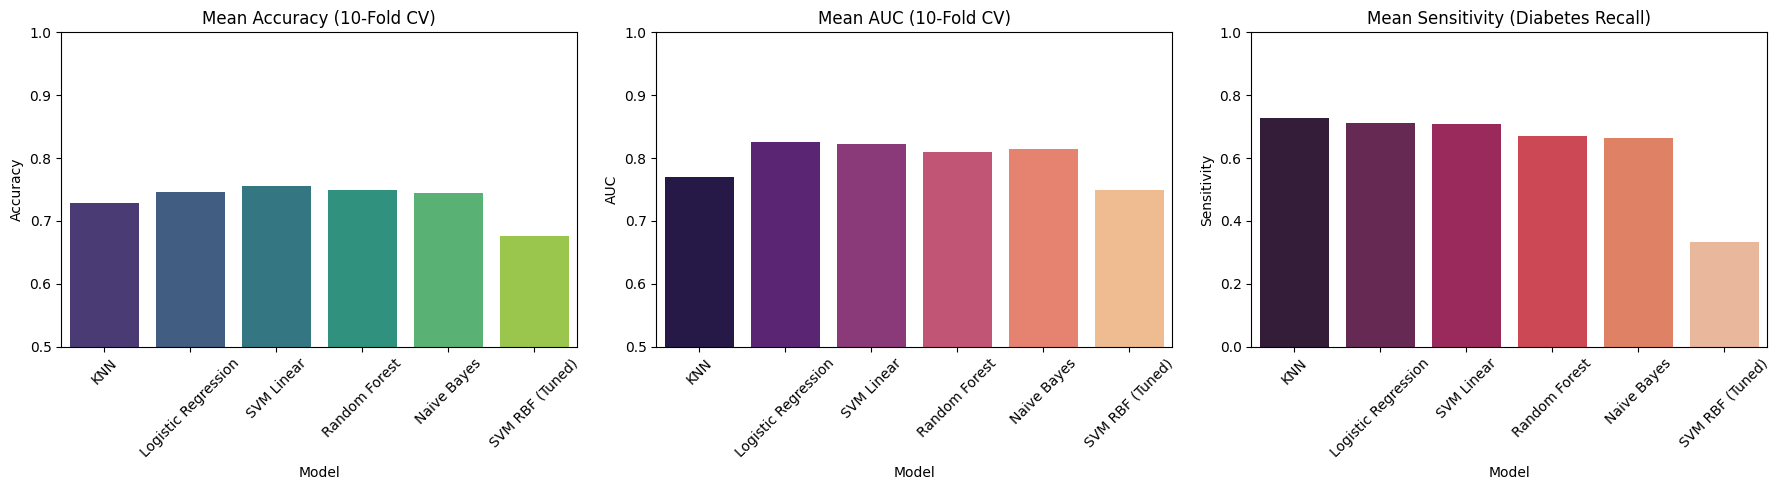

In [19]:
# Create a DataFrame for easy comparison
cv_df = pd.DataFrame(results_list).sort_values(by='Sensitivity', ascending=False)

print("\n--- Detailed 10-Fold CV Results (Sorted by Sensitivity) ---")
display(cv_df)

# Plotting the comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(x='Model', y='Accuracy', data=cv_df, ax=axes[0], palette='viridis')
axes[0].set_title('Mean Accuracy (10-Fold CV)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylim(0.5, 1.0)

sns.barplot(x='Model', y='AUC', data=cv_df, ax=axes[1], palette='magma')
axes[1].set_title('Mean AUC (10-Fold CV)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylim(0.5, 1.0)

sns.barplot(x='Model', y='Sensitivity', data=cv_df, ax=axes[2], palette='rocket')
axes[2].set_title('Mean Sensitivity (Diabetes Recall)')
axes[2].tick_params(axis='x', rotation=45)
axes[2].set_ylim(0.0, 1.0)

plt.tight_layout()
plt.show()

### Different Naive Bayes with Feature Engineeeing

In [20]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris, make_classification
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score, classification_report

def advanced_feature_engineering(X_train_res, X_test, y_train_res):
    """Advanced feature engineering pipeline"""
    
    n_features = X_train_res.shape[1]
    k_features = min(6, n_features)  
    
    #feature scaling for GaussianNB
    scaler_gaussian = StandardScaler()
    X_train_gaussian = scaler_gaussian.fit_transform(X_train_res)
    X_test_gaussian = scaler_gaussian.transform(X_test)
    
    #feature scaling for MultinomialNB (non-negative values)
    scaler_multinomial = MinMaxScaler()
    X_train_multinomial = scaler_multinomial.fit_transform(X_train_res)
    X_test_multinomial = scaler_multinomial.transform(X_test)
    
    #feature selection - only if we have enough features
    if n_features > 3:  
        selector = SelectKBest(score_func=f_classif, k=k_features)
        X_train_selected = selector.fit_transform(X_train_res, y_train_res)
        X_test_selected = selector.transform(X_test)
    else:
        X_train_selected = X_train_res
        X_test_selected = X_test
    
    return {
        'gaussian': (X_train_gaussian, X_test_gaussian),
        'multinomial': (X_train_multinomial, X_test_multinomial),
        'selected': (X_train_selected, X_test_selected),
        'original': (X_train_res, X_test)
    }

# feature engineering
print(f"Original data shape: {X_train_res.shape}")
feature_sets = advanced_feature_engineering(X_train_res, X_test, y_train_res)

# training different Naive Bayes models
models = {
    'GaussianNB': GaussianNB(),
    'MultinomialNB': MultinomialNB(),
    'BernoulliNB': BernoulliNB()
}

results = {}

for model_name, model in models.items():
    print(f"\n{model_name} Results:")
    print("=" * 50)
    
    for feature_set_name, (X_train_feat, X_test_feat) in feature_sets.items():
        #skip incompatible combinations
        if model_name == 'MultinomialNB' and feature_set_name == 'gaussian':
            print(f"{feature_set_name:15}: SKIPPED (negative values)")
            continue
            
        #use y_train_res (SMOTE data) for training
        model.fit(X_train_feat, y_train_res)  
        
        y_pred = model.predict(X_test_feat)
        
        accuracy = accuracy_score(y_test, y_pred)
        
        results[f"{model_name}_{feature_set_name}"] = accuracy
        print(f"{feature_set_name:15}: {accuracy:.4f}")

#display results
print("\n" + "=" * 60)
print("BEST RESULTS:")
print("=" * 60)
for model_accuracy in sorted(results.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"{model_accuracy[0]:25}: {model_accuracy[1]:.4f}")


Original data shape: (700, 8)

GaussianNB Results:
gaussian       : 0.7619
multinomial    : 0.7619
selected       : 0.7576
original       : 0.7619

MultinomialNB Results:
gaussian       : SKIPPED (negative values)
multinomial    : 0.6234
selected       : 0.5498
original       : 0.5758

BernoulliNB Results:
gaussian       : 0.7013
multinomial    : 0.5584
selected       : 0.5411
original       : 0.5844

BEST RESULTS:
GaussianNB_gaussian      : 0.7619
GaussianNB_multinomial   : 0.7619
GaussianNB_original      : 0.7619
GaussianNB_selected      : 0.7576
BernoulliNB_gaussian     : 0.7013


**Stacked Ensemble with Feature Engineering**

In [21]:
import numpy as np
import pandas as pd
from sklearn.ensemble import StackingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.feature_selection import SelectKBest, f_classif
import warnings
warnings.filterwarnings('ignore')

#check numpy version
print(f"NumPy version: {np.__version__}")

def safe_advanced_ensemble(X_train, y_train, X_test, y_test):
    """
    Advanced ensemble using pre-split training and test data
    """
    if hasattr(X_train, 'values'):
        X_train = X_train.values
    if hasattr(y_train, 'values'):
        y_train = y_train.values
    if hasattr(X_test, 'values'):
        X_test = X_test.values
    if hasattr(y_test, 'values'):
        y_test = y_test.values
    
    #scale both train and test
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    #define base models with compatibility fixes
    base_models = [
        ('rf', RandomForestClassifier(
            n_estimators=100,
            max_depth=8,
            min_samples_split=5,
            min_samples_leaf=2,
            random_state=42
        )),
        ('gb', GradientBoostingClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=5,
            random_state=42
        )),
        ('svm', SVC(
            C=1.0,
            kernel='rbf',
            probability=True,
            random_state=42
        )),
        ('mlp', MLPClassifier(
            hidden_layer_sizes=(50, 25),
            activation='relu',
            alpha=0.01,
            learning_rate='adaptive',
            max_iter=500,
            random_state=42
        ))
    ]
    
    #meta-model
    meta_model = LogisticRegression(
        C=0.1,
        penalty='l2',
        random_state=42,
        max_iter=1000
    )
    
    #create stacking ensemble
    ensemble = StackingClassifier(
        estimators=base_models,
        final_estimator=meta_model,
        cv=3,
        passthrough=False,
        n_jobs=1
    )
    
    #training ensemble on SMOTE-resampled training data
    print("Training advanced ensemble on SMOTE data...")
    ensemble.fit(X_train_scaled, y_train)
    
    #predictions on test set
    y_pred = ensemble.predict(X_test_scaled)
    y_pred_proba = ensemble.predict_proba(X_test_scaled)[:, 1]
    
    accuracy = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba)
    
    print(f"Ensemble Accuracy: {accuracy:.4f}")
    print(f"Ensemble AUC: {auc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['No Diabetes', 'Diabetes']))
    
    #confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:")
    print(cm)
    
    return ensemble, scaler, accuracy, auc

def safe_feature_engineering(X, y=None):
    """
    Create medically relevant features with compatibility fixes
    """
    #convert to DataFrame for easier manipulation
    if not isinstance(X, pd.DataFrame):
        #Create generic column names if needed
        if len(X.shape) > 1:
            columns = [f'feature_{i}' for i in range(X.shape[1])]
            X_df = pd.DataFrame(X, columns=columns)
        else:
            X_df = pd.DataFrame(X)
    else:
        X_df = X.copy()
    
    #medical composite scores (with safe column access)
    numeric_columns = X_df.select_dtypes(include=[np.number]).columns
    
    if len(numeric_columns) >= 3:
        #use first three numeric columns for composite scores
        col1, col2, col3 = numeric_columns[:3]
        X_df['composite_score_1'] = (X_df[col1] / X_df[col1].mean()) + \
                                   (X_df[col2] / X_df[col2].mean()) + \
                                   (X_df[col3] / X_df[col3].mean())
    
    if len(numeric_columns) >= 2:
        #interaction terms
        col1, col2 = numeric_columns[:2]
        X_df['interaction_1'] = X_df[col1] * X_df[col2]
        X_df['ratio_1'] = X_df[col1] / (X_df[col2] + 1e-8)  #avoid division by zero
    
    #polynomial features for first few numeric columns
    for i, col in enumerate(numeric_columns[:3]):
        X_df[f'{col}_squared'] = X_df[col] ** 2
        X_df[f'{col}_log'] = np.log1p(np.abs(X_df[col]))  #safe log
    
    #fill any NaN values
    X_df = X_df.fillna(X_df.mean())
    
    return X_df

def enhanced_safe_workflow(X_train_res, y_train_res, X_test, y_test, use_feature_engineering=True):
    """
    Complete workflow using pre-processed SMOTE data
    """
    print("Enhanced diabetes prediction workflow")
    print(f"Training data shape: {X_train_res.shape}")
    print(f"Test data shape: {X_test.shape}")
    print(f"Training class distribution: {np.bincount(y_train_res)}")
    print(f"Test class distribution: {np.bincount(y_test)}")
    
    if use_feature_engineering:
        # feature engineering
        X_train_enhanced = safe_feature_engineering(X_train_res)
        X_test_enhanced = safe_feature_engineering(X_test)
        
        print(f"Original training features: {X_train_res.shape[1]}")
        print(f"Enhanced training features: {X_train_enhanced.shape[1]}")
        print(f"Original test features: {X_test.shape[1]}")
        print(f"Enhanced test features: {X_test_enhanced.shape[1]}")
    else:
        #use original features
        X_train_enhanced = X_train_res
        X_test_enhanced = X_test
        print("Using original features (no feature engineering)")
    
    #create and evaluate ensemble
    print("2. Training advanced ensemble model...")
    ensemble, scaler, accuracy, auc = safe_advanced_ensemble(
        X_train_enhanced, y_train_res, X_test_enhanced, y_test
    )
    
    return ensemble, scaler, accuracy, auc

#without feature engineering
def quick_ensemble_evaluation(X_train_res, y_train_res, X_test, y_test):
    """
    Quick ensemble evaluation without feature engineering
    """
    print("=== QUICK STACKING ENSEMBLE EVALUATION ===")
    
    ensemble, scaler, accuracy, auc = safe_advanced_ensemble(
        X_train_res, y_train_res, X_test, y_test
    )
    
    print(f"FINAL RESULTS:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"AUC: {auc:.4f}")
  
    return ensemble, scaler, accuracy, auc
    
# Run the quick evaluation with your data
print("Using your SMOTE-resampled training data and original test data...")
ensemble_model, scaler, accuracy, auc = quick_ensemble_evaluation(
    X_train_res, y_train_res, X_test, y_test
)

#with feature engineering
print("\n" + "="*60)
print("RUNNING WITH FEATURE ENGINEERING")
print("="*60)

try:
    ensemble_enhanced, scaler_enhanced, accuracy_enhanced, auc_enhanced = enhanced_safe_workflow(
        X_train_res, y_train_res, X_test, y_test, use_feature_engineering=True
    )
    
    print(f"COMPARISON:")
    print(f"Without feature engineering - Accuracy: {accuracy:.4f}, AUC: {auc:.4f}")
    print(f"With feature engineering    - Accuracy: {accuracy_enhanced:.4f}, AUC: {auc_enhanced:.4f}")
    
except Exception as e:
    print(f"Feature engineering failed: {e}")
    print("Using results from quick evaluation instead.")

NumPy version: 2.3.4
Using your SMOTE-resampled training data and original test data...
=== QUICK STACKING ENSEMBLE EVALUATION ===
Training advanced ensemble on SMOTE data...
Ensemble Accuracy: 0.7662
Ensemble AUC: 0.8198

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.80      0.85      0.82       150
    Diabetes       0.68      0.62      0.65        81

    accuracy                           0.77       231
   macro avg       0.74      0.73      0.74       231
weighted avg       0.76      0.77      0.76       231

Confusion Matrix:
[[127  23]
 [ 31  50]]
FINAL RESULTS:
Accuracy: 0.7662
AUC: 0.8198

RUNNING WITH FEATURE ENGINEERING
Enhanced diabetes prediction workflow
Training data shape: (700, 8)
Test data shape: (231, 8)
Training class distribution: [350 350]
Test class distribution: [150  81]
Original training features: 8
Enhanced training features: 17
Original test features: 8
Enhanced test features: 17
2. Training advanced ensem